In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/quora-insincere-questions-classification/test.csv
/kaggle/input/quora-insincere-questions-classification/train.csv
/kaggle/input/quora-insincere-questions-classification/sample_submission.csv
/kaggle/input/quora-insincere-questions-classification/embeddings/GoogleNews-vectors-negative300/GoogleNews-vectors-negative300.bin
/kaggle/input/quora-insincere-questions-classification/embeddings/glove.840B.300d/glove.840B.300d.txt
/kaggle/input/quora-insincere-questions-classification/embeddings/wiki-news-300d-1M/wiki-news-300d-1M.vec
/kaggle/input/quora-insincere-questions-classification/embeddings/paragram_300_sl999/README.txt
/kaggle/input/quora-insincere-questions-classification/embeddings/paragram_300_sl999/paragram_300_sl999.txt


In [2]:
#https://www.kaggle.com/c/quora-insincere-questions-classification
path='/kaggle/input/quora-insincere-questions-classification/train.csv'
train=pd.read_csv(path,nrows=1000)
train.head()

,qid,question_text,target
0,00002165364db923c7e6,How did Quebec nationalists see their province...,0
1,000032939017120e6e44,"Do you have an adopted dog, how would you enco...",0
2,0000412ca6e4628ce2cf,Why does velocity affect time? Does velocity a...,0
3,000042bf85aa498cd78e,How did Otto von Guericke used the Magdeburg h...,0
4,0000455dfa3e01eae3af,Can I convert montra helicon D to a mountain b...,0


* target=0 means question can be asked in public forum
* target=1 means insincere question
* qid is just the ID -- we can ignore

#Methods to convert text to numerical values
- Document term Matrix
- Using word2vec/Doc2vec

#Text cleaning
- Convert every character to lower case
- Using regular expression retain only alphabets (sometime numbers,#&@)
- Remove commonly used words
- Identify root from the word(stemming,lemmatization)

In [3]:
#Converting every character to lower case
docs=train['question_text'].str.lower()
print(docs.head())
print('\n')

#Remove non-alphabets
docs.str.replace('[^a-z ]','')
print(docs.head())
print('\n')

#Remove commonly used words
import nltk
stopwords=nltk.corpus.stopwords.words('english')
stemmer=nltk.stem.PorterStemmer()
print(stopwords)
print('\n')

def clean_sentence(doc):
    words=doc.split(' ')
    words_clean=[stemmer.stem(word) for word in words if word not in stopwords]
    return ' '.join(words_clean)
    print(words_clean)
    
docs=docs.apply(clean_sentence)


0    how did quebec nationalists see their province...
1    do you have an adopted dog, how would you enco...
2    why does velocity affect time? does velocity a...
3    how did otto von guericke used the magdeburg h...
4    can i convert montra helicon d to a mountain b...
Name: question_text, dtype: object


0    how did quebec nationalists see their province...
1    do you have an adopted dog, how would you enco...
2    why does velocity affect time? does velocity a...
3    how did otto von guericke used the magdeburg h...
4    can i convert montra helicon d to a mountain b...
Name: question_text, dtype: object


['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'tho

# converting aplhabets into numbers - document term matrix
 To normalize in text mining.
* Term frquency(TF)
* Inverse doccumnet Frequency(IDF)

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

dtm_vectorizer = CountVectorizer()


train_x,validate_x, train_y,validate_y = train_test_split(docs, train['target'], test_size = 0.2, random_state = 1)
dtm_vectorizer.fit(train_x)
dtm_train = dtm_vectorizer.transform(train_x)
dtm_validate = dtm_vectorizer.transform(validate_x)

In [5]:
dtm_train

<800x2709 sparse matrix of type '<class 'numpy.int64'>'
	with 5046 stored elements in Compressed Sparse Row format>

In [6]:
df_dtm_train = pd.DataFrame(dtm_train.toarray(),columns=dtm_vectorizer.get_feature_names(),index=train_x.index)
df_dtm_train

,00,000,06,10,100,1000,1000cc,10r,10th,11,...,yolk,york,yorkie,you,youtub,youtube,zealand,zero,zindagi,zx
382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
994,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
982,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
47,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
521,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
72,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
908,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


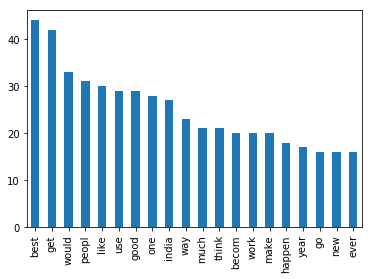

In [7]:
df_dtm_train.sum().sort_values(ascending=False).head(20).plot.bar()

In [8]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB().fit(dtm_train,train_y)
train_y_pred=model.predict(dtm_validate)

from sklearn.metrics import accuracy_score,f1_score
print(accuracy_score(validate_y,train_y_pred))
print(f1_score(validate_y,train_y_pred))


0.965
0.22222222222222224


In [9]:
#Sentiment Analysis
from nltk.sentiment import SentimentIntensityAnalyzer
sentiment_analyzer=SentimentIntensityAnalyzer()
sentiment_analyzer.polarity_scores('i like india')

/opt/conda/lib/python3.6/site-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


{'neg': 0.0, 'neu': 0.286, 'pos': 0.714, 'compound': 0.3612}